# 08 — Finite attack duration and rational quitting (sections 19-21)
Deadlines, start-time sensitivity, and abandonment thresholds.

In [1]:
%matplotlib inline
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt

import src.experiments as EX
import src.plotting as PL

cfg = EX.load_config("../config/defaults.yaml")
TRIALS = 5000
print("config loaded; primary q =", cfg["attacker_shares"]["primary"])

config loaded; primary q = 0.1


R1: {'600s × 1': [0.0004, 0.0014, 0.0074, 0.0234, 0.1482, 0.1964, 0.1866, 0.2076], '60s × 1': [0.023, 0.1124, 0.1822, 0.2002, 0.1936, 0.203, 0.1866, 0.2076], '60s × 2': [0.001, 0.0046, 0.037, 0.057, 0.0574, 0.0572, 0.0554, 0.0546], '60s × 3': [0.0, 0.0, 0.0044, 0.0146, 0.0186, 0.016, 0.0182, 0.0162], '60s × 5': [0.0, 0.0, 0.0, 0.0006, 0.0012, 0.001, 0.0008, 0.0004], '60s × 10': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}


R2: [('simultaneous', 0.061), ('at_inclusion', 0.0606), ('reactive_0s', 0.0508), ('reactive_10s', 0.0542), ('reactive_30s', 0.0518), ('reactive_60s', 0.0504), ('reactive_120s', 0.0488), ('reactive_300s', 0.055), ('reactive_600s', 0.054), ('premining_-3', 0.0006), ('premining_-2', 0.0016), ('premining_-1', 0.007), ('premining_+0', 0.0532), ('premining_+1', 0.2858), ('premining_+2', 1.0), ('premining_+3', 1.0)]
R3: [('never', 0.057), ('abandon_at_1', 0.0494), ('abandon_at_2', 0.0458), ('abandon_at_3', 0.0516), ('abandon_at_5', 0.056), ('abandon_at_10', 0.054), ('abandon_at_20', 0.0578), ('abandon_at_50', 0.0582)]


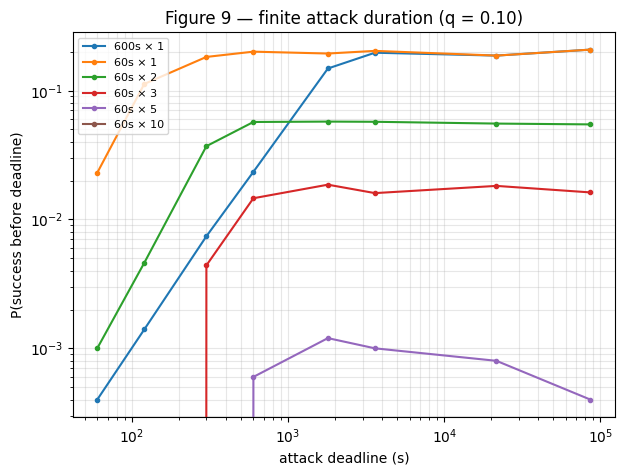

In [2]:
r1 = EX.r1_finite_duration(cfg, trials=TRIALS)
print("R1:", {k: [round(p["p_hat"], 4) for p in v] for k, v in r1.data["curves"].items()})
r2 = EX.r2_start_time(cfg, trials=TRIALS)
print("R2:", [(s["scenario"], round(s["p_hat"], 4)) for s in r2.data["scenarios"]])
r3 = EX.r3_abandonment(cfg, trials=TRIALS)
print("R3:", [(s["scenario"], round(s["p_hat"], 4)) for s in r3.data["scenarios"]])

fig = PL.fig9_finite_duration(cfg, results={"R1": r1})
plt.show()